# Missing values & duplication


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
dfi = pd.read_csv("/content/beauty_amazon_items.csv")
dfi.head()

,Description,Title,Brand,Price,ItemId
0,Loud 'N Clear Personal Sound Amplifier allows ...,Loud 'N Clear&trade; Personal Sound Amplifier,idea village,NaN,P4924
1,No7 Lift & Luminate Triple Action Serum 50ml b...,No7 Lift &amp; Luminate Triple Action Serum 50...,NaN,$44.99,P4622
2,No7 Stay Perfect Foundation now stays perfect ...,No7 Stay Perfect Foundation Cool Vanilla by No7,No7,$28.76,P6435
3,NaN,Wella Koleston Perfect Hair Colour 44/44 Mediu...,NaN,NaN,P4623
4,Lacto Calamine Skin Balance Daily Nourishing L...,Lacto Calamine Skin Balance Oil control 120 ml...,Pirmal Healthcare,$12.15,P7


In [ ]:
dfi.info()
dfi.head()
dfi.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32890 entries, 0 to 32889
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Description  14581 non-null  object
 1   Title        32889 non-null  object
 2   Brand        17214 non-null  object
 3   Price        11459 non-null  object
 4   ItemId       32890 non-null  object
dtypes: object(5)
memory usage: 1.3+ MB


,Description,Title,Brand,Price,ItemId
count,14581,32889,17214,11459,32890
unique,13272,32297,7860,3529,32486
top,"For over 60 years, Betty Dain Creations, Inc. ...",Baubax Women's Bomber Travel Jacket,VAGA,$9.99,P4745
freq,59,9,252,214,2


In [ ]:
# a lot of missing values

In [ ]:
dfi[dfi['Title'].isnull()]

,Description,Title,Brand,Price,ItemId
27016,NaN,NaN,BCW,$2.89 - $13.99,P3733


In [ ]:
#P3733 no tittle no description

In [ ]:
# Fill in missing tittle w blank
dfi['Title'] = dfi['Title'].fillna('')

# Fill missing Description with empty string
dfi['Description'] = dfi['Description'].fillna('')

# Missing brand = unknown
dfi['Brand'] = dfi['Brand'].fillna('Unknown')

dfi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32890 entries, 0 to 32889
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Description  32890 non-null  object
 1   Title        32890 non-null  object
 2   Brand        32890 non-null  object
 3   Price        11459 non-null  object
 4   ItemId       32890 non-null  object
dtypes: object(5)
memory usage: 1.3+ MB


In [ ]:
# Missing values for Price
# Clean price
dfi['Price'] = dfi['Price'].astype(str).replace('[\$,]', '', regex=True)
dfi['Price'] = pd.to_numeric(dfi['Price'], errors='coerce')

# Impute price per brand where possible
dfi['Price'] = dfi.groupby('Brand')['Price'].transform(lambda x: x.fillna(x.median()))

# Fill remaining with global median
dfi['Price'] = dfi['Price'].fillna(dfi['Price'].median())


In [ ]:
dfi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32890 entries, 0 to 32889
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Description  32890 non-null  object 
 1   Title        32890 non-null  object 
 2   Brand        32890 non-null  object 
 3   Price        32890 non-null  float64
 4   ItemId       32890 non-null  object 
dtypes: float64(1), object(4)
memory usage: 1.3+ MB


In [ ]:
# Check for duplicate item ID
duplicate_item_ids = dfi['ItemId'].duplicated()

# Count the number of duplicate
num_duplicate_item_ids = duplicate_item_ids.sum()

print(f"Number of duplicate itemIDs: {num_duplicate_item_ids}")

# Display rows with duplicate values
if num_duplicate_item_ids > 0:
    print("\nRows with duplicate ItemId:")
    duplicate_rows = dfi[dfi['ItemId'].duplicated(keep=False)].sort_values('ItemId')
    display(duplicate_rows)
else:
    print("No duplicate ItemId found.")

Number of duplicate itemIDs: 404

Rows with duplicate ItemId:


,Description,Title,Brand,Price,ItemId
22,This high-tech shaver comes with an LCD indica...,Norelco 6885XL Deluxe Quadra Action Cord/Cordl...,Norelco,19.990,P10
426,This high-tech shaver comes with an LCD indica...,Norelco 6885XL Deluxe Quadra Action Cord/Cordl...,Norelco,19.990,P10
696,,NARS Powder Blush Cheek Color,NARS,32.000,P100
292,,NARS Powder Blush Cheek Color,NARS,32.000,P100
305,Get a powder and foundation combined in one po...,Clinique Superpowder Double Face Makeup for Dr...,Clinique,31.820,P101
...,...,...,...,...,...
297,Enhance surface cellular renewal to diminish t...,DERMA E Anti-Wrinkle Renewal Cream with Vitami...,DERMA-E,10.490,P99
107,For Manicures & Pedicures Fully Charged Unit W...,"Conair Manicure Rechargeable Kit, White",Conair,9.915,P9908
511,For Manicures & Pedicures Fully Charged Unit W...,"Conair Manicure Rechargeable Kit, White",Conair,9.915,P9908
611,,"Gabriel ORGANICS, Red Seaweed Purifying Tonic,...",Gabriel Organics,21.380,P9960


In [ ]:
# Remove duplicate rows based on 'itemID', keeping the first occurrence
dfi= dfi.drop_duplicates(subset=['ItemId'], keep='first')

print(f"Original number of rows in dfi: {len(dfi)}")
print(f"Number of rows after removing duplicates: {len(dfi)}")

Original number of rows in dfi: 32486
Number of rows after removing duplicates: 32486


In [ ]:
dfi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32486 entries, 0 to 32889
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Description  32486 non-null  object 
 1   Title        32486 non-null  object 
 2   Brand        32486 non-null  object 
 3   Price        32486 non-null  float64
 4   ItemId       32486 non-null  object 
dtypes: float64(1), object(4)
memory usage: 1.5+ MB


In [ ]:
dfr = pd.read_csv("/content/beauty_amazon_reviews.csv")
dfr.head()


,Rating,Time,UserId,ItemId,Review,Summary
0,1.0,"02 19, 2015",U0,P0,great,One Star
1,4.0,"12 18, 2014",U1,P0,My husband wanted to reading about the Negro ...,... to reading about the Negro Baseball and th...
2,4.0,"08 10, 2014",U2,P0,"This book was very informative, covering all a...",Worth the Read
3,5.0,"03 11, 2013",U3,P0,I am already a baseball fan and knew a bit abo...,Good Read
4,5.0,"12 25, 2011",U4,P0,This was a good story of the Black leagues. I ...,"More than facts, a good story read!"


In [ ]:
dfr.info()
dfr.head()
dfr.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371345 entries, 0 to 371344
Data columns (total 6 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Rating   371345 non-null  float64
 1   Time     371345 non-null  object 
 2   UserId   371345 non-null  object 
 3   ItemId   371345 non-null  object 
 4   Review   370936 non-null  object 
 5   Summary  371132 non-null  object 
dtypes: float64(1), object(5)
memory usage: 17.0+ MB


,Rating,Time,UserId,ItemId,Review,Summary
count,371345.000000,371345,371345,371345,370936,371132
unique,NaN,5288,324038,32586,319642,183396
top,NaN,"03 1, 2016",U53180,P1358,Good,Five Stars
freq,NaN,515,27,8672,802,69967
mean,4.112093,NaN,NaN,NaN,NaN,NaN
std,1.362099,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,4.000000,NaN,NaN,NaN,NaN,NaN
50%,5.000000,NaN,NaN,NaN,NaN,NaN
75%,5.000000,NaN,NaN,NaN,NaN,NaN


In [ ]:
# we have to deal with the review. this can be exaplain that people do not comment on the product.

In [ ]:
# Fill missing 'Review' and 'Summary' with blank strings
dfr['Review'] = dfr['Review'].fillna('')
dfr['Summary'] = dfr['Summary'].fillna('')

dfr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371345 entries, 0 to 371344
Data columns (total 6 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Rating   371345 non-null  float64
 1   Time     371345 non-null  object 
 2   UserId   371345 non-null  object 
 3   ItemId   371345 non-null  object 
 4   Review   371345 non-null  object 
 5   Summary  371345 non-null  object 
dtypes: float64(1), object(5)
memory usage: 17.0+ MB


In [ ]:
# for duplicate, I chose to remove those witht the same time, same itemid and same review

# Check for duplicate rows based on 'Id', 'Review', and 'Time'
duplicate_reviews = dfr.duplicated(subset=['ItemId', 'Review', 'Time'])

# Count the number of duplicate reviews
num_duplicate_reviews = duplicate_reviews.sum()

print(f"Number of duplicate reviews (same ItemId, Review, and Time): {num_duplicate_reviews}")

# Display rows with duplicate values
if num_duplicate_reviews > 0:
    print("\nRows with duplicate reviews (same ItemId, Review, and Time):")
    duplicate_rows_dfr = dfr[dfr.duplicated(subset=['ItemId', 'Review', 'Time'], keep=False)].sort_values(['ItemId', 'Time', 'Review'])
    display(duplicate_rows_dfr)
else:
    print("No duplicate reviews found (same ItemId, Review, and Time).")

Number of duplicate reviews (same ItemId, Review, and Time): 8773

Rows with duplicate reviews (same ItemId, Review, and Time):


,Rating,Time,UserId,ItemId,Review,Summary
107925,5.0,"10 14, 2014",U92512,P1060,Great,Five Stars
107926,5.0,"10 14, 2014",U92513,P1060,Great,Five Stars
18374,5.0,"01 3, 2017",U18263,P114,Great Product I am 55 people think I am in my ...,Five Stars
18375,5.0,"01 3, 2017",U18263,P114,Great Product I am 55 people think I am in my ...,Five Stars
18581,5.0,"08 30, 2013",U18456,P114,I am 31 years old and over the last few years ...,Awesome
...,...,...,...,...,...,...
257155,5.0,"09 25, 2014",U221962,P76,I don't know why they stopped making this!!! I...,It worked as good if not better than rx
272381,1.0,"08 11, 2014",U235741,P856,The quality is badddd!!!!!!!!,One Star
272382,1.0,"08 11, 2014",U235741,P856,The quality is badddd!!!!!!!!,One Star
15829,5.0,"05 19, 2008",U15742,P95,This hair color works just as well as regular ...,Great Product


In [ ]:
# Remove duplicate rows based on 'ItemId', 'Review', and 'Time', keeping the first occurrence
print(f"Original number of rows in dfr: {len(dfr)}")

dfr = dfr.drop_duplicates(subset=['ItemId', 'Review', 'Time'], keep='first').copy()

print(f"Number of rows after removing duplicates: {len(dfr)}")

Original number of rows in dfr: 371345
Number of rows after removing duplicates: 362572


In [ ]:
dfr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 362572 entries, 0 to 371344
Data columns (total 6 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Rating   362572 non-null  float64
 1   Time     362572 non-null  object 
 2   UserId   362572 non-null  object 
 3   ItemId   362572 non-null  object 
 4   Review   362572 non-null  object 
 5   Summary  362572 non-null  object 
dtypes: float64(1), object(5)
memory usage: 19.4+ MB


#  Explore data and create test set

## Analysis - Items Dataset

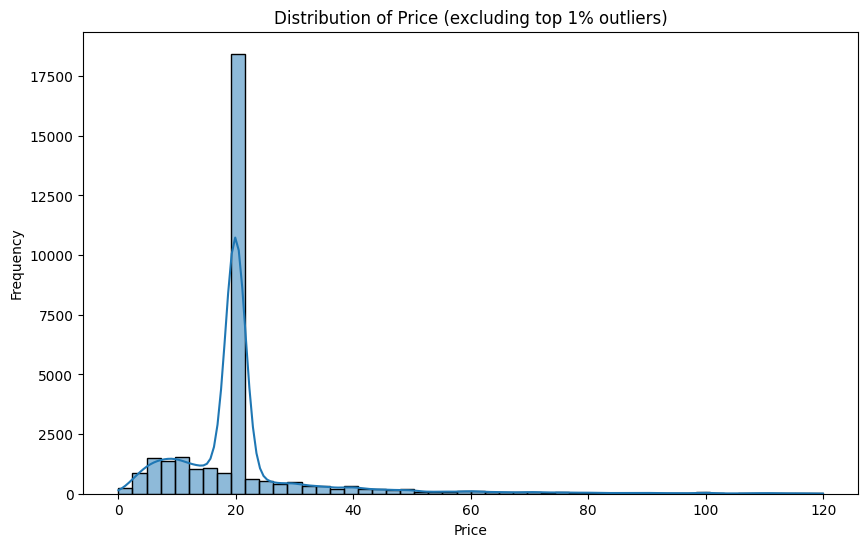

In [ ]:
# Distribution of Price
upper_price_limit = dfi['Price'].quantile(0.99) # Get the 99th percentile price

plt.figure(figsize=(10, 6))
sbn.histplot(dfi[dfi['Price'] < upper_price_limit]['Price'], kde=True, bins=50)
plt.title('Distribution of Price (excluding top 1% outliers)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Print rows where Price is 0, to make sure no outlier
print("Items with a price of 0:")
items_with_zero_price = dfi[dfi['Price'] == 0]
if not items_with_zero_price.empty:
    display(items_with_zero_price)
else:
    print("No items found with a price of 0.")

Items with a price of 0:
No items found with a price of 0.


In [ ]:
# we can see that most of the product costed around $20

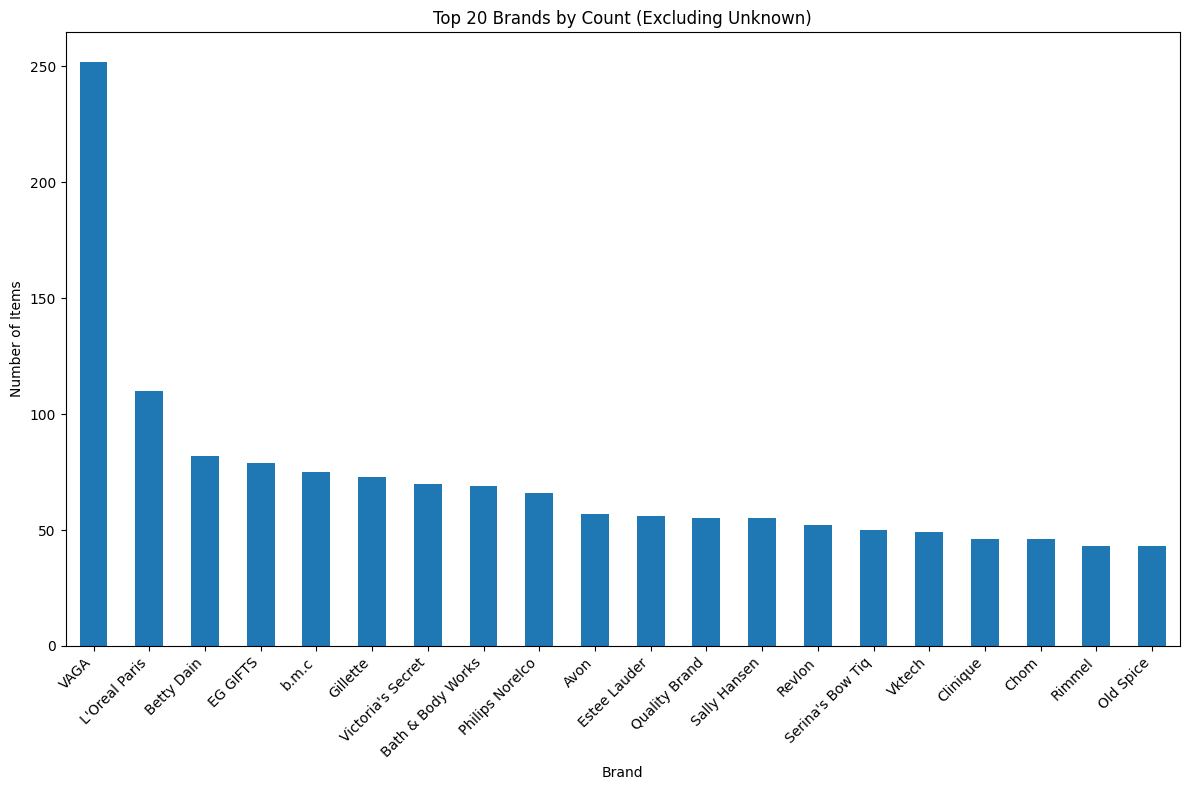

In [ ]:
# Top 20 Brands by count (Excluding Unknown)
plt.figure(figsize=(12, 8))
dfi[dfi['Brand'] != 'Unknown']['Brand'].value_counts().nlargest(20).plot(kind='bar')
plt.title('Top 20 Brands by Count (Excluding Unknown)')
plt.xlabel('Brand')
plt.ylabel('Number of Items')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# we can see that VAGA, Loreal and Betty Dain were the best-selling brands

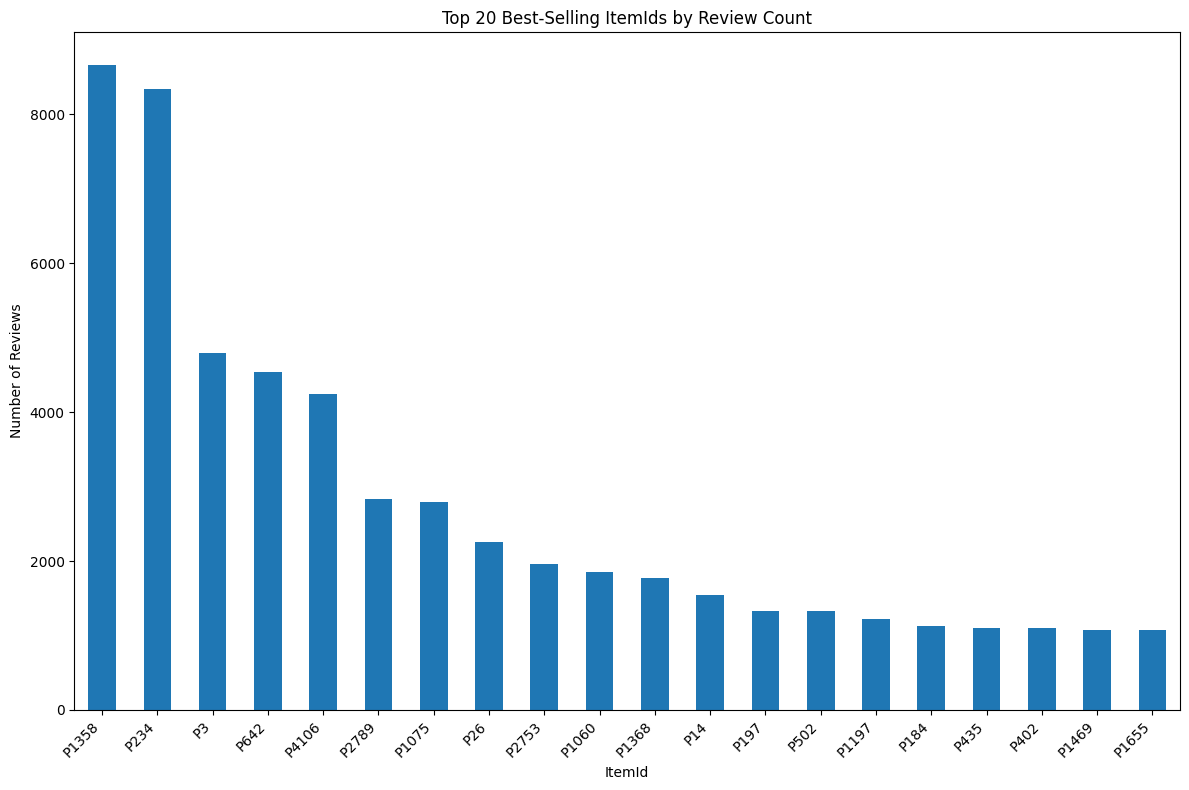

In [ ]:
# Best selling items
item_review_counts = dfr['ItemId'].value_counts()

# Select the top 20 ItemIds with the highest counts
top_20_best_selling_item_ids = item_review_counts.nlargest(20)

# Create the bar chart
plt.figure(figsize=(12, 8))
top_20_best_selling_item_ids.plot(kind='bar')

plt.title('Top 20 Best-Selling ItemIds by Review Count')
plt.xlabel('ItemId')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [ ]:
dfi[dfi["ItemId"]== "P1358"]

,Description,Title,Brand,Price,ItemId
1254,Premium dental water jet with dramatically imp...,Waterpik Ultra Water Flosser,Waterpik,84.99,P1358


In [ ]:
dfi[dfi["ItemId"]== "P234"]

,Description,Title,Brand,Price,ItemId
1374,Premium dental water jet with dramatically imp...,Waterpik Ultra Water Flosser,Waterpik,84.99,P234


In [ ]:
dfi[dfi["ItemId"]== "P3"]

,Description,Title,Brand,Price,ItemId


In [ ]:
dfi[dfi["ItemId"]== "P642"]

,Description,Title,Brand,Price,ItemId
3605,ASTRA stainless double edge blades fit all dou...,Astra Platinum Double Edge Safety Razor Blades...,Astra,9.3,P642


In [ ]:
# The first 2 best selling is the same stuff which is a stuff to clean teeth
# The 3rd best selling product idk wt is it so i chose the 4th one
# The 4th one is a shaving stuff for men

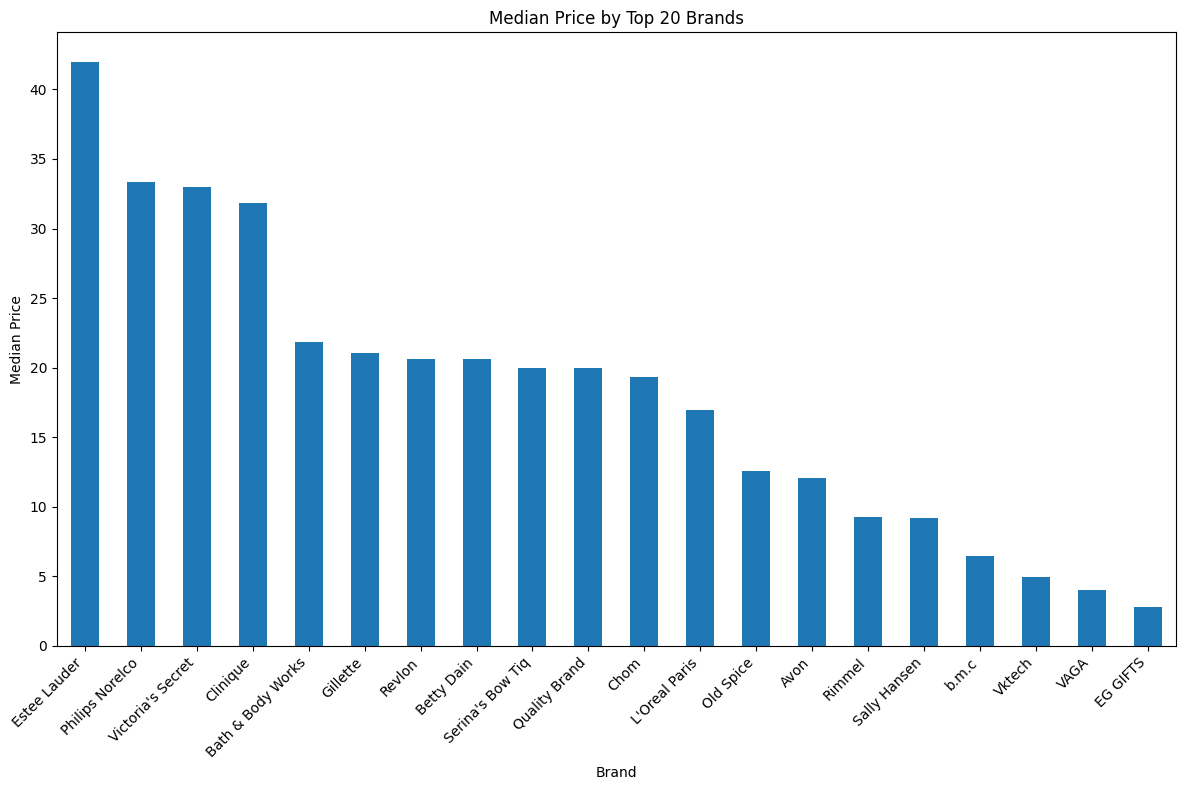

In [ ]:
## Plot the relationship between Brand and Price (Median Price for Top 20 Brands)

brand_median_prices = dfi.groupby('Brand')['Price'].median()
top_20_brands = dfi[dfi['Brand'] != 'Unknown']['Brand'].value_counts().nlargest(20).index
median_prices_top_brands = brand_median_prices.loc[top_20_brands]
median_prices_top_brands = median_prices_top_brands.sort_values(ascending=False)


# Create the bar chart
plt.figure(figsize=(12, 8))
median_prices_top_brands.plot(kind='bar')

plt.title('Median Price by Top 20 Brands')
plt.xlabel('Brand')
plt.ylabel('Median Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# we can see that the median price of Estee Lauder, Philips Norelco and Victoria Secret are the most expensive ones

## Analysis - Review Dataset

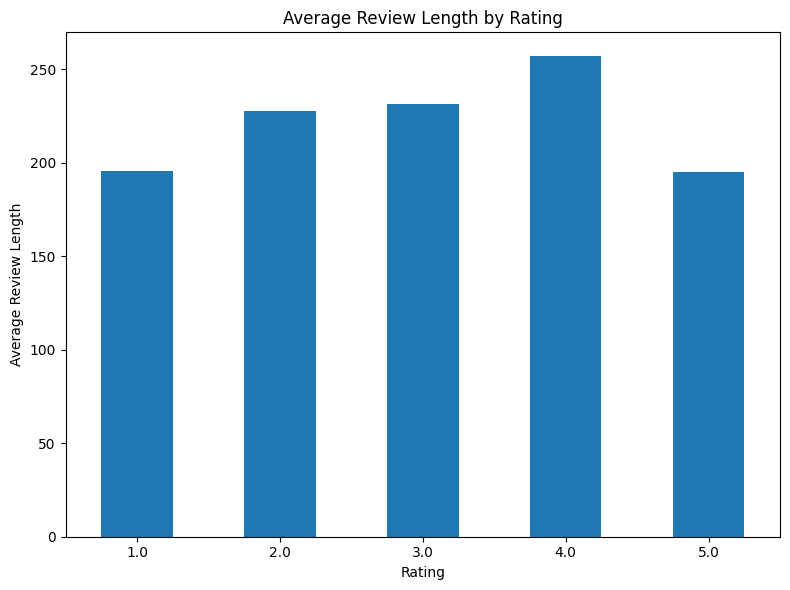

In [ ]:
# 1. Calculate Summary Length
dfr['Review_Length'] = dfr['Review'].str.len()

# 2. Group by Rating and Analyze Summary Length
summary_length_by_rating = dfr.groupby('Rating')['Review_Length'].mean()

# 3. Visualize the Relationship
plt.figure(figsize=(8, 6))
summary_length_by_rating.plot(kind='bar')
plt.title('Average Review Length by Rating')
plt.xlabel('Rating')
plt.ylabel('Average Review Length')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# we can see that the rating with 4 stars mostly has a longer length of review from consumers

## Analysis of the two dataset

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.11/dist-packages/matplotlib/pyplot.py'>

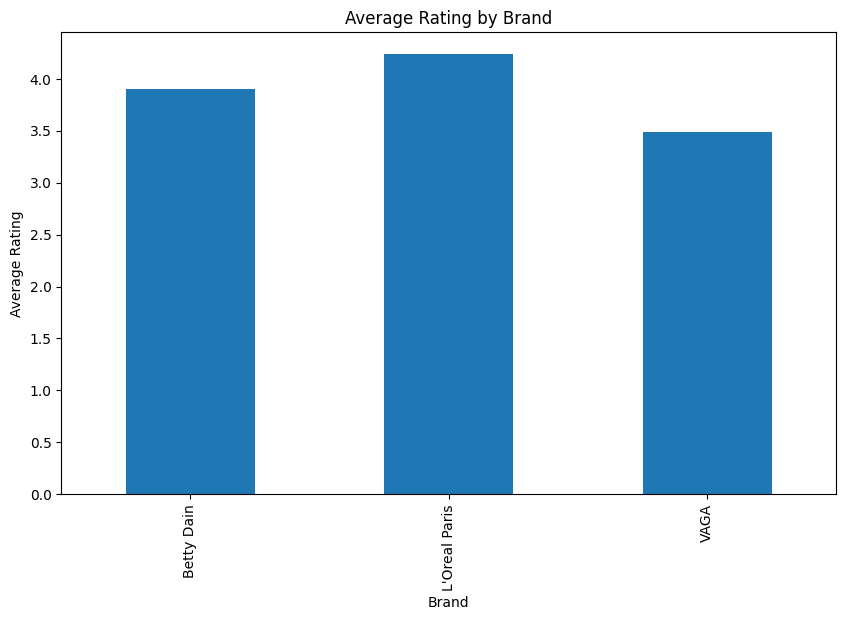

In [ ]:
merged_df = pd.merge(dfi, dfr, on='ItemId', how='left')

# Fidning the average rating for the top 3 most popular brand
target_brands = ['VAGA', "L'Oreal Paris", 'Betty Dain']
filtered_brands = merged_df[merged_df['Brand'].isin(target_brands)]
avg_ratings = filtered_brands.groupby('Brand')['Rating'].mean()

# Create the bar chart
plt.figure(figsize=(10, 6))
avg_ratings.plot(kind='bar')
plt.title('Average Rating by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Rating')
plt

In [ ]:
# we can see that L'Oreal has the highest rating with above 4.

## Create test set


In [ ]:
dfr.head()

,Rating,Time,UserId,ItemId,Review,Summary,Review_Length
0,1.0,"02 19, 2015",U0,P0,great,One Star,5
1,4.0,"12 18, 2014",U1,P0,My husband wanted to reading about the Negro ...,... to reading about the Negro Baseball and th...,170
2,4.0,"08 10, 2014",U2,P0,"This book was very informative, covering all a...",Worth the Read,61
3,5.0,"03 11, 2013",U3,P0,I am already a baseball fan and knew a bit abo...,Good Read,111
4,5.0,"12 25, 2011",U4,P0,This was a good story of the Black leagues. I ...,"More than facts, a good story read!",366


In [ ]:
# we can see the time format is mm/dd/yy

In [ ]:
dfr['Time'] = pd.to_datetime(dfr['Time'], format='%m %d, %Y')

In [ ]:
# Sort reviews by time (earliest first)
dfr_sorted = dfr.sort_values('Time')

# Create 80/20 train-test split based on time
split_index = int(0.8 * len(dfr_sorted))
train_dfr = dfr_sorted.iloc[:split_index]
test_dfr = dfr_sorted.iloc[split_index:]

#only split the interaction data (reviews), becoz it contains time and reflects actual user behavior over time

# Popularity Model

In the popularity-based recommendation model, I analyzed product interactions from the training dataset to identify the most popular items. This involved ranking items by total number of reviews and average ratings, both overall and specifically for the most recent year in the dataset. I visualized the top 20 most-reviewed products and computed summary statistics on review counts. To capture temporal dynamics, I also compared item popularity between earlier years (2014–2015) and more recent years (2016–2017) to identify trending products. Finally, I evaluated the effectiveness of three recommendation strategies—overall most popular, recent most popular, and trending items—using Precision@20 based on actual item interactions from the 2018 test set.

## All-Time Popular Products

In [ ]:
# Most Reviewed Products (overall)
popular_all = train_dfr.groupby('ItemId').size().reset_index(name='num_reviews')
popular_all = popular_all.sort_values(by='num_reviews', ascending=False)
display(popular_all.head())

,ItemId,num_reviews
3706,P1358,8464
13589,P234,8161
19551,P3,4379
25223,P642,3630
631,P1060,1818


In [ ]:
# we can see that these are the most number of review's

In [ ]:
# Highest Rated Products
popular_rated = train_dfr.groupby('ItemId').agg(
    avg_rating=('Rating', 'mean'),
    num_reviews=('Rating', 'count')
)

#show the top 5
display(popular_rated.head())

,avg_rating,num_reviews
ItemId,,
P0,4.000000,15
P1,3.916667,12
P10,3.967742,31
P100,4.595238,42
P1000,4.769231,13


In [ ]:
# but this is not a fair comparison as some only have 20 reviews comapre to those that have 8k reviews
# therefore, we need to sort the product that at least has a certain numbers of review

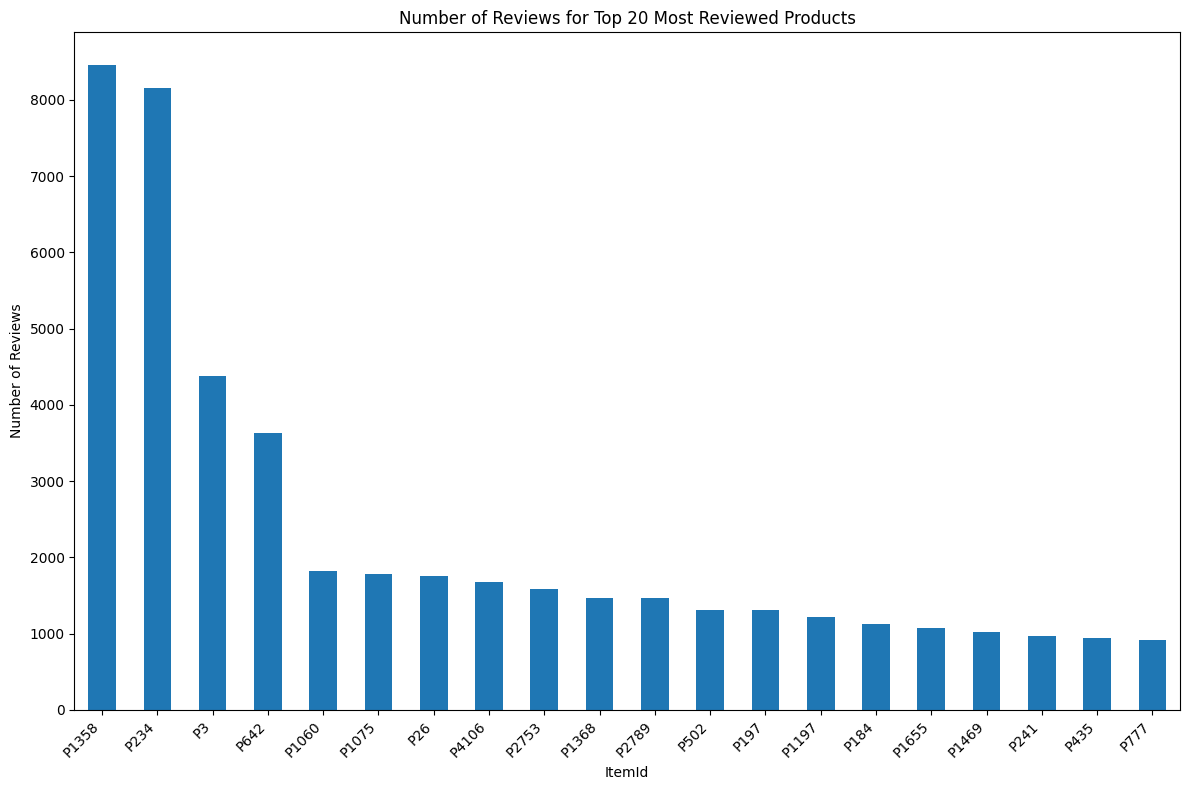

In [ ]:
# Calculate the number of reviews for each item
item_review_counts = train_dfr.groupby('ItemId').size()

# Sort the items by review count in descending order and select the top 20
top_20_reviewed_items = item_review_counts.sort_values(ascending=False).head(20)

# Create a bar chart
plt.figure(figsize=(12, 8))
top_20_reviewed_items.plot(kind='bar')

plt.title('Number of Reviews for Top 20 Most Reviewed Products')
plt.xlabel('ItemId')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# as the barchart, i think is a good idea to set the minimum review to 500

In [ ]:
# Filter: Only products with at least 500 reviews
popular_rated = popular_rated[popular_rated['num_reviews'] >= 500]
popular_rated = popular_rated.sort_values(by='avg_rating', ascending=False)

print(popular_rated.head())

        avg_rating  num_reviews
ItemId                         
P435      4.961012          949
P205      4.960227          704
P155      4.960227          704
P369      4.956471          850
P40       4.930743          592


In [ ]:
# yeah, we remove all the one w less than 500 reviews
# and now make things clearer

In [ ]:
top_10_item_ids = popular_rated.head(10).index

for item_id in top_10_item_ids:
    num_reviews = len(train_dfr[train_dfr['ItemId'] == item_id])
    average_rating = popular_rated.loc[item_id, 'avg_rating']
    print(f"Item {item_id} has {num_reviews} review(s) and an average rating of {average_rating:.2f}.")

Item P435 has 949 review(s) and an average rating of 4.96.
Item P205 has 704 review(s) and an average rating of 4.96.
Item P155 has 704 review(s) and an average rating of 4.96.
Item P369 has 850 review(s) and an average rating of 4.96.
Item P40 has 592 review(s) and an average rating of 4.93.
Item P632 has 634 review(s) and an average rating of 4.92.
Item P3 has 4379 review(s) and an average rating of 4.81.
Item P1075 has 1783 review(s) and an average rating of 4.67.
Item P1655 has 1070 review(s) and an average rating of 4.65.
Item P1469 has 1017 review(s) and an average rating of 4.61.


## Most Popular Products 2017

In [ ]:
# Define the latest year
latest_year = train_dfr['Time'].dt.year.max()
current_year_df = train_dfr[train_dfr['Time'].dt.year == latest_year]

display(current_year_df.head())

,Rating,Time,UserId,ItemId,Review,Summary,Review_Length
305533,2.0,2017-01-01,U265628,P16136,The mirror was broke when we opened it,Two Stars,38
253975,5.0,2017-01-01,U219066,P4470,Bought these for the wife. She absolutely love...,Wife gives two thumbs up.,178
251290,1.0,2017-01-01,U216579,P4377,Hard to take off,One Star,16
247852,4.0,2017-01-01,U213367,P4226,This is a very nice product and would have giv...,This is a very nice product and would have giv...,94
237717,1.0,2017-01-01,U203974,P4044,What a joke and waste of money. My daughter wa...,Garbage! Absolute waste of money.,231


In [ ]:
# so we know now is 2018 for the current year :)

In [ ]:
# Most Reviewed in Current Year
popular_now = current_year_df.groupby('ItemId').size().reset_index(name='num_reviews')
popular_now = popular_now.sort_values(by='num_reviews', ascending=False)

In [ ]:
current_year_df["ItemId"].value_counts()[:10]

,count
ItemId,
P4106,550
P3,342
P642,306
P1075,277
P2753,256
P4352,141
P2789,137
P26,130
P1368,107


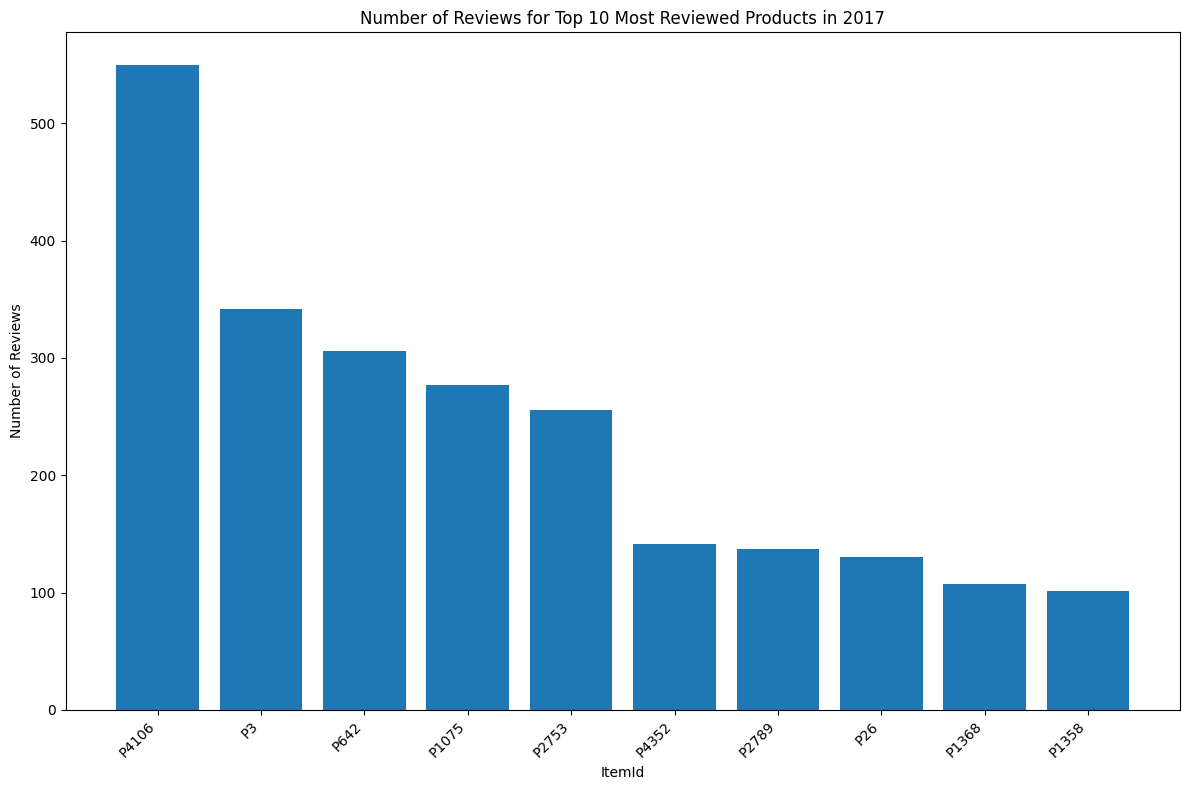

In [ ]:
# Get the top 10 most reviewed items in the current year
top_10_popular_now = popular_now.head(10)

# Create the bar chart
plt.figure(figsize=(12, 8))
plt.bar(top_10_popular_now['ItemId'], top_10_popular_now['num_reviews'])

plt.title(f'Number of Reviews for Top 10 Most Reviewed Products in {latest_year}')
plt.xlabel('ItemId')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# we can sew that P4106 has the most number of reviwed this year
# let's do the same as the all time popular product

In [ ]:
print("Summary stats of number of reviews per item:")
print(popular_all['num_reviews'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

Summary stats of number of reviews per item:
count    29000.000000
mean        10.001966
std         89.225819
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
90%         14.000000
95%         31.000000
99%        136.000000
max       8464.000000
Name: num_reviews, dtype: float64


In [ ]:
# I will take the 90th percentiles as the minimum reviews number which is 16

In [ ]:
# now remove all the items less than 16 reviews
rated_now = current_year_df.groupby('ItemId').agg(
    avg_rating=('Rating', 'mean'),
    num_reviews=('Rating', 'count')
)
rated_now = rated_now[rated_now['num_reviews'] >= 16]
rated_now = rated_now.sort_values(by='avg_rating', ascending=False)


In [ ]:
top_10_current_year_item_ids = rated_now.head(10).index

print(f"\nTop 10 Highest Rated Items (with >= 16 reviews) in {latest_year}:")
for item_id in top_10_current_year_item_ids:
    num_reviews_current_year = len(current_year_df[current_year_df['ItemId'] == item_id])
    average_rating_current_year = rated_now.loc[item_id, 'avg_rating']
    print(f"Item {item_id} has {num_reviews_current_year} review(s) and an average rating of {average_rating_current_year:.2f}.")


Top 10 Highest Rated Items (with >= 16 reviews) in 2017:
Item P57 has 24 review(s) and an average rating of 5.00.
Item P417 has 16 review(s) and an average rating of 5.00.
Item P899 has 17 review(s) and an average rating of 5.00.
Item P625 has 22 review(s) and an average rating of 5.00.
Item P556 has 18 review(s) and an average rating of 5.00.
Item P205 has 32 review(s) and an average rating of 4.97.
Item P155 has 32 review(s) and an average rating of 4.97.
Item P96 has 26 review(s) and an average rating of 4.96.
Item P369 has 58 review(s) and an average rating of 4.95.
Item P435 has 58 review(s) and an average rating of 4.95.


## Trending product

In [ ]:
earliest_year = train_dfr['Time'].dt.year.min()
print(f"Earliest year in the dataset: {earliest_year}")

Earliest year in the dataset: 2000


In [ ]:
train_dfr.loc[:, 'year'] = train_dfr['Time'].dt.year

recent_years = [2016, 2017]
previous_years = [2014, 2015]

/tmp/ipython-input-137-3724663083.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_dfr.loc[:, 'year'] = train_dfr['Time'].dt.year


In [ ]:
#  Count Interactions per Item in Each Period
views_recent = train_dfr[train_dfr['year'].isin(recent_years)].groupby('ItemId').size()
views_previous = train_dfr[train_dfr['year'].isin(previous_years)].groupby('ItemId').size()


In [ ]:
# Check distribution
views_previous.describe()

,0
count,13740.000000
mean,7.685153
std,50.203693
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,2586.000000


In [ ]:
# Filter Items with Enough Past Reviews
threshold = views_previous.quantile(0.75) #0.75 which is 4
filtered_ids = views_previous[views_previous >= threshold].index

In [ ]:
trend = (views_recent / views_previous)[filtered_ids] - 1
trending_items = trend.sort_values(ascending=False).head(10)

# Format nicely for percentage growth
formatted_trend = trending_items.apply(lambda x: f"{x:+.0%}" if x > 0 else f"{x:.0%}")
print(formatted_trend)

ItemId
P3275    +3040%
P2895    +2812%
P3151    +2350%
P3559    +1950%
P3251    +1340%
P3067    +1276%
P3171    +1275%
P4106    +1254%
P2573    +1225%
P2362    +1125%
dtype: object


In [ ]:
# wow we can see that P3275 reviews have increase so much in 2016 n 2017 compare to 2014 n 2015

In [ ]:
for item in trending_items.index:
    print(f"Item ID {item} was reviewed {views_previous[item]} times in 2014–2015 and {views_recent.get(item, 0)} times in 2016–2017.")

Item ID P3275 was reviewed 5 times in 2014–2015 and 157 times in 2016–2017.
Item ID P2895 was reviewed 8 times in 2014–2015 and 233 times in 2016–2017.
Item ID P3151 was reviewed 4 times in 2014–2015 and 98 times in 2016–2017.
Item ID P3559 was reviewed 14 times in 2014–2015 and 287 times in 2016–2017.
Item ID P3251 was reviewed 5 times in 2014–2015 and 72 times in 2016–2017.
Item ID P3067 was reviewed 37 times in 2014–2015 and 509 times in 2016–2017.
Item ID P3171 was reviewed 4 times in 2014–2015 and 55 times in 2016–2017.
Item ID P4106 was reviewed 115 times in 2014–2015 and 1557 times in 2016–2017.
Item ID P2573 was reviewed 4 times in 2014–2015 and 53 times in 2016–2017.
Item ID P2362 was reviewed 4 times in 2014–2015 and 49 times in 2016–2017.


## Test set

Method: By comparing my model’s predictions to the actual most popular items in 2018 (from test_dfr) to see the performance of the model.

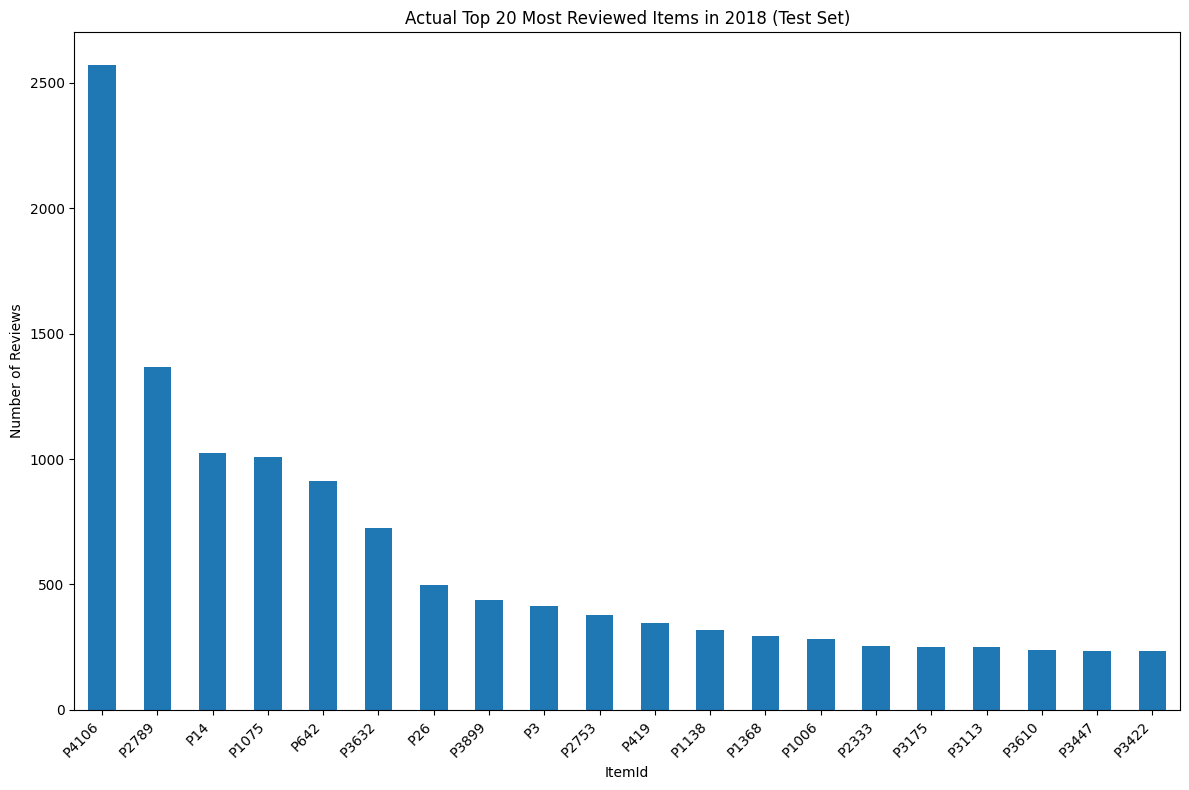

In [ ]:
actual_popular_2018 = test_dfr['ItemId'].value_counts().head(20)
actual_top_2018_items = actual_popular_2018.index

plt.figure(figsize=(12, 8))
actual_popular_2018.plot(kind='bar')

plt.title('Actual Top 20 Most Reviewed Items in 2018 (Test Set)')
plt.xlabel('ItemId')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Evaluation of the model
def precision_at_k(predicted, actual, k=20):
    predicted_set = set(predicted[:k])
    actual_set = set(actual[:k])
    return len(predicted_set & actual_set) / k

# Model predictions
rec_all_time = popular_all['ItemId'].head(20).values
rec_2017 = popular_now['ItemId'].head(20).values
rec_trending = trending_items.index[:20].values

# Evaluate
print("All-Time Popular Precision@20:", precision_at_k(rec_all_time, actual_top_2018_items))
print("2017 Popular Precision@20:", precision_at_k(rec_2017, actual_top_2018_items))
print("Trending Popular Precision@20:", precision_at_k(rec_trending, actual_top_2018_items))


All-Time Popular Precision@20: 0.4
2017 Popular Precision@20: 0.45
Trending Popular Precision@20: 0.05


We can see that my model is performing quite bad
BUT
although trending products showed momentum, they did not align well with 2018’s bestsellers. The most accurate model was the one based on 2017 popularity

Moreover, the model based on 2017 popularity gave the best Precision@20 at 0.45, slightly better than using all-time popular items (0.40). This shows that recent trends are more useful for predicting what users liked in 2018. The trending items model didn’t do well (0.05), meaning sudden spikes in popularity didn’t help much for future recommendations. Overall, using recent data seems to work best here.


Improvement


*   Segmented Popularity - for example, most popular items within each brand
Or most popular per user cluster (e.g., frequent reviewers)



# Content-based model

In [ ]:
import re
import numpy as np
import pandas as pd
from pprint import pprint

np.set_printoptions(linewidth=np.inf)
pd.options.mode.chained_assignment = None  # Deactivate a Pandas' warning

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler

## Preproccess

There are 4 variables to deal with:

* tittle
* description
* brand
* Price

In [ ]:
# combine feature
# i will conbined the tittle + description + brand into one column

# Make a copy
dfi_copy = dfi.copy()

# Clean Title and Description
for col in ['Title', 'Description']:
    dfi_copy[col] = (
        dfi_copy[col]
        .fillna('')
        .astype(str)
        .str.replace('unknown', '', case=False)
        .str.strip()
    )

# Combine textual features
dfi_copy['combined_features'] = dfi_copy['Title'] + ' ' + dfi_copy['Description']

# n not removing these columns cause we will use for another model later

In [ ]:
print(dfi_copy['combined_features'].str.contains('unknown', case=False).sum())

0


In [ ]:
# Normalize price
scaler = MinMaxScaler()
dfi_copy['normalized_price'] = scaler.fit_transform(dfi_copy[['Price']])

TextVectorization

In [ ]:
# TF-IDF for combined text
tfidf = TfidfVectorizer(stop_words='english', max_features=500)
tfidf_matrix = tfidf.fit_transform(dfi_copy['combined_features'])

# Convert to DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out(), index=dfi_copy.index)

# Merge with dfi_copy
dfi_copy = pd.concat([dfi_copy, tfidf_df], axis=1)

# Drop unused
dfi_copy.drop(['Title', 'Description', 'Price', 'combined_features'], axis=1, inplace=True)

# Define final feature columns
feature_cols = tfidf.get_feature_names_out().tolist() + ['normalized_price']


Mapping

In [ ]:
# Filter train/test to only valid items
valid_items = set(dfi_copy['ItemId'])
train_dfr = train_dfr[train_dfr['ItemId'].isin(valid_items)]
test_dfr = test_dfr[test_dfr['ItemId'].isin(valid_items)]

# Map Item and User IDs to numeric indices
item_id_map = {id_: idx for idx, id_ in enumerate(dfi_copy['ItemId'].unique())}
user_id_map = {id_: idx for idx, id_ in enumerate(train_dfr['UserId'].unique())}

dfi_copy['item_idx'] = dfi_copy['ItemId'].map(item_id_map)
train_dfr['user_idx'] = train_dfr['UserId'].map(user_id_map)
train_dfr['item_idx'] = train_dfr['ItemId'].map(item_id_map)
test_dfr['user_idx'] = test_dfr['UserId'].map(user_id_map)
test_dfr['item_idx'] = test_dfr['ItemId'].map(item_id_map)

test_dfr = test_dfr[test_dfr['user_idx'].notna()].copy() # Filter out users not in the training set
test_dfr['user_idx'] = test_dfr['user_idx'].astype(int) # Convert to integer after filtering
test_dfr = test_dfr[test_dfr['item_idx'].notna()].copy() # Filter out items not in the item features
test_dfr['item_idx'] = test_dfr['item_idx'].astype(int) # Convert to integer after filtering


In [ ]:
test_dfr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3741 entries, 308283 to 371130
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Rating         3741 non-null   float64       
 1   Time           3741 non-null   datetime64[ns]
 2   UserId         3741 non-null   object        
 3   ItemId         3741 non-null   object        
 4   Review         3741 non-null   object        
 5   Summary        3741 non-null   object        
 6   Review_Length  3741 non-null   int64         
 7   user_idx       3741 non-null   int64         
 8   item_idx       3741 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 292.3+ KB


Build user profile

In [ ]:
# Item features matrix
item_features = dfi_copy.set_index('item_idx')[feature_cols].copy()

# Merge ratings with item features
df_combined = pd.merge(train_dfr, dfi_copy[['item_idx'] + feature_cols], on='item_idx', how='inner')

#  Weight by rating:
# for col in feature_cols:
#     df_combined[col] = df_combined[col] * (df_combined['Rating'] / 5)

# Average to build user profiles
user_profiles = df_combined.groupby('user_idx')[feature_cols].mean()



At first i was planning to use weight by rating to improve the precision of the model as it focuses the user profile on preferred features (from high-rated items). It reduces the influence of items the user didn’t like. But then after doing that and I printed out the shape, the shape of item feature n user feature are not the same. I tried to impletement some changed but still no way the shape is the same for both features.

In [ ]:
dfi_copy.head()

,Brand,ItemId,normalized_price,10,100,11,12,13,14,15,...,wild,women,work,works,world,wrap,wrinkle,wrinkles,years,item_idx
0,idea village,P4924,0.009279,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,Unknown,P4622,0.020931,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,No7,P6435,0.013378,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,Unknown,P4623,0.009279,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,Pirmal Healthcare,P7,0.005649,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


In [ ]:
train_dfr.head()

,Rating,Time,UserId,ItemId,Review,Summary,Review_Length,year,user_idx,item_idx
256161,5.0,2000-10-29,U221070,P4630,"Very good shaver, I have always purchased Nore...",Fabulous Shaver,191,2000,0,25
5299,5.0,2000-11-12,U5298,P16,Talk about a smooth shave. The blades are clo...,This shaver rocks!,251,2000,1,30
256259,5.0,2000-11-21,U221163,P4634,"I've had a beard for, let's see, 20 years now,...",Great design,1858,2000,2,24
256185,5.0,2000-11-27,U221091,P4633,I got this for my fiance. he has the softest f...,Awesome,101,2000,3,23
256258,5.0,2000-11-28,U221162,P4634,"Where I work , a certain airline, moustaches a...",A Good Product,230,2000,4,24


In [ ]:
# # i see that after doing the mapping, there are nan in the item idx of the dfr.
# # this maybe due to a mismatch
# # therefore i have to:

# missing_ids = set(train_dfr['ItemId']) - set(dfi_copy['ItemId'])
# print("Missing ItemIds in dfi_copy:", missing_ids)


In [ ]:
print("NaNs in train_dfr['ItemId']:", train_dfr['item_idx'].isna().sum())


NaNs in train_dfr['ItemId']: 0


## Aggregation and Similarity Measure with Explicit Feedbacks

In [ ]:
print("Item feature shape:", item_features.shape)
print("User profile shape:", user_profiles.shape)

# This should print same number:
print("Feature mismatch:", item_features.shape[1] != user_profiles.shape[1])

# idk what i have done before (probably i do the weight by rating) and so the shape is not the same....
# therefore, i decided to not do weight by rating

Item feature shape: (32486, 501)
User profile shape: (254138, 501)
Feature mismatch: False


In [ ]:
item_features.head()

,10,100,11,12,13,14,15,16,18,20,...,wild,women,work,works,world,wrap,wrinkle,wrinkles,years,normalized_price
item_idx,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.009279
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.020931
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.013378
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.009279
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.005649


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity


def recommend_for_user(user_idx, top_n=10):
    if user_idx not in user_profiles.index:
        return []

    user_vector = user_profiles.loc[user_idx].values.reshape(1, -1)
    sim_scores = cosine_similarity(user_vector, item_features.values).flatten()

    seen_items = train_dfr[train_dfr['user_idx'] == user_idx]['item_idx'].values
    sim_scores[seen_items] = -1  # mask seen

    top_indices = sim_scores.argsort()[::-1][:top_n]
    return [(idx, sim_scores[idx]) for idx in top_indices]


Evaluation of the model

In [ ]:
# Evaluation of the model
def precision_at_k(user_idx, k=10, test_df=None, recommender_func=None):
    if recommender_func is None or test_df is None:
        raise ValueError("Must provide recommender_func and test_df.")

    recommended = recommender_func(user_idx, top_n=k)
    recommended_item_ids = [item[0] for item in recommended]
    actual = set(test_df[test_df['user_idx'] == user_idx]['item_idx'])

    if not actual:
        return None

    hits = len(set(recommended_item_ids) & actual)
    return hits / k


In [ ]:
# Evaluate all users
user_indices = test_dfr['user_idx'].dropna().unique()
scores = [precision_at_k(uid, k=10, test_df=test_dfr, recommender_func=recommend_for_user) for uid in user_indices]
scores = [s for s in scores if s is not None]

print(f"Content-Based Precision@10: {np.mean(scores):.4f}")

Content-Based Precision@10: 0.0021


At first the precison is 0 which then I realised the problem is i'm using `user_id` in my `precision_at_k() `evaluation, but my recommender function `recommend_for_user()`expects `user_idx` (the mapped integer).

I dont know why the precision is super low. I tried to use recall instead and the result is still the same. Moreoever, I tried to add a Filter test users with too few training interactions + Filter test items that weren’t seen during training. But still.

I also tried to increase the max feature for text vectorization to 200 n precision increases but still so bad, i think one of the improvement will be increase it to 500, but then it may probably run out of RAM...

# Collaborative filtering model

The flow will be first do the prerpocess and then we will do the model-based

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Preprocess

In [ ]:
dfi.head()

,Description,Title,Brand,Price,ItemId
0,Loud 'N Clear Personal Sound Amplifier allows ...,Loud 'N Clear&trade; Personal Sound Amplifier,idea village,19.95,P4924
1,No7 Lift & Luminate Triple Action Serum 50ml b...,No7 Lift &amp; Luminate Triple Action Serum 50...,Unknown,44.99,P4622
2,No7 Stay Perfect Foundation now stays perfect ...,No7 Stay Perfect Foundation Cool Vanilla by No7,No7,28.76,P6435
3,,Wella Koleston Perfect Hair Colour 44/44 Mediu...,Unknown,19.95,P4623
4,Lacto Calamine Skin Balance Daily Nourishing L...,Lacto Calamine Skin Balance Oil control 120 ml...,Pirmal Healthcare,12.15,P7


In [ ]:
dfr.head()

,Rating,Time,UserId,ItemId,Review,Summary,Review_Length
0,1.0,2015-02-19,U0,P0,great,One Star,5
1,4.0,2014-12-18,U1,P0,My husband wanted to reading about the Negro ...,... to reading about the Negro Baseball and th...,170
2,4.0,2014-08-10,U2,P0,"This book was very informative, covering all a...",Worth the Read,61
3,5.0,2013-03-11,U3,P0,I am already a baseball fan and knew a bit abo...,Good Read,111
4,5.0,2011-12-25,U4,P0,This was a good story of the Black leagues. I ...,"More than facts, a good story read!",366


In [ ]:
# Create a copy of the train_dfr DataFrame
train_dfr_2 = train_dfr.copy()

# Create a copy of the test_dfr DataFrame
test_dfr_2 = test_dfr.copy()


In [ ]:
test_dfr_2['UserId'].unique()

array(['U102719', 'U311138', 'U275035', ..., 'U321661', 'U321754', 'U321813'], dtype=object)

In [ ]:
len(test_dfr_2['ItemId'].unique())

11810

In [ ]:
a = set(test_dfr_2['UserId'].unique())
b = set(train_dfr_2['UserId'].unique())

users_to_test = a.intersection(b)
users_to_test

{'U177432',
 'U198323',
 'U173475',
 'U37242',
 'U105295',
 'U34614',
 'U51972',
 'U167639',
 'U120137',
 'U161694',
 'U62434',
 'U25423',
 'U221308',
 'U294012',
 'U45',
 'U17215',
 'U148635',
 'U122537',
 'U123347',
 'U134843',
 'U143479',
 'U60228',
 'U75916',
 'U19257',
 'U13199',
 'U43823',
 'U20411',
 'U83105',
 'U101149',
 'U29880',
 'U208915',
 'U106859',
 'U101817',
 'U98320',
 'U40967',
 'U63496',
 'U311217',
 'U80850',
 'U74814',
 'U103000',
 'U194627',
 'U169623',
 'U163488',
 'U48363',
 'U160026',
 'U149036',
 'U26023',
 'U177604',
 'U175829',
 'U47092',
 'U121063',
 'U101330',
 'U76880',
 'U21881',
 'U126576',
 'U120563',
 'U90192',
 'U7162',
 'U71100',
 'U20019',
 'U13856',
 'U23688',
 'U54421',
 'U187544',
 'U229934',
 'U199571',
 'U160795',
 'U155346',
 'U310905',
 'U30541',
 'U6086',
 'U121539',
 'U313618',
 'U24488',
 'U260412',
 'U184886',
 'U94154',
 'U133018',
 'U83761',
 'U24593',
 'U103486',
 'U105682',
 'U109540',
 'U17210',
 'U192093',
 'U68940',
 'U185056',
 

## Memory-Based : Item-Item

I will use item-item meaning that recommend items similar to what the user already liked. This will be done by similarity is computed between items based on how users rated them

Building

count    2310.000000
mean        2.784848
std         1.208471
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
90%         4.000000
95%         4.000000
max        10.000000
Name: count, dtype: float64
count    134.000000
mean      48.007463
std      131.150404
min        4.000000
25%       10.000000
50%       13.000000
75%       19.750000
90%       53.500000
95%      367.900000
max      892.000000
Name: count, dtype: float64


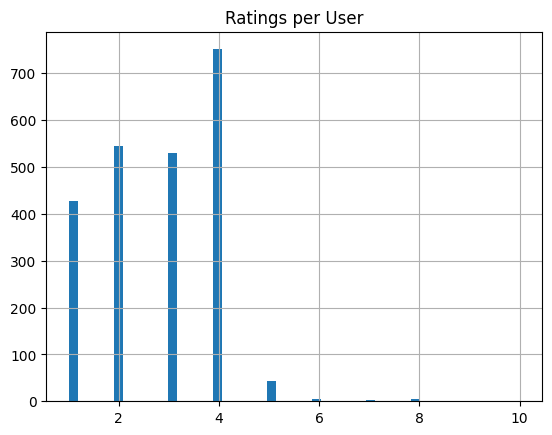

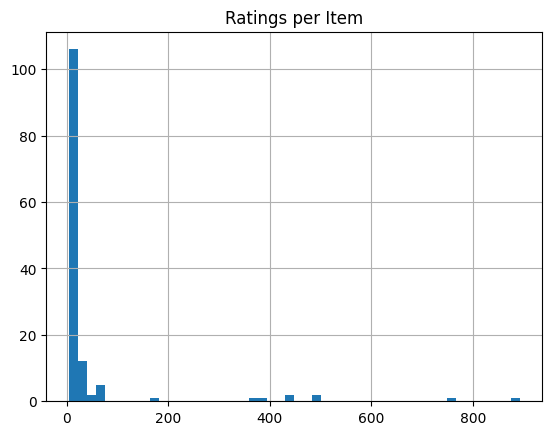

In [ ]:
# Cold start filter
# Filtering out users with very few ratings
# Filtering out items with very few ratings

# Step 1: setting the threholds for both users and items

# Ratings per user
user_counts = train_dfr_2['UserId'].value_counts()
print(user_counts.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))

# Ratings per item
item_counts = train_dfr_2['ItemId'].value_counts()
print(item_counts.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))

user_counts.hist(bins=50)
plt.title("Ratings per User")
plt.show()

item_counts.hist(bins=50)
plt.title("Ratings per Item")
plt.show()



`min_user_ratings = 3`: This will filter out the vast majority of extremely inactive users
Keeps only those who gave at least 3 interactions, enabling meaningful similarity calculations

`min_item_ratings = 10`: Filters out items with very few ratings, which are unreliable for similarity
Keeps items in the top ~15–20% based on popularity (above the 75th percentile)

In [ ]:
# Cold start filtering
min_user_ratings = 3
min_item_ratings = 10

# Count interactions
user_counts = train_dfr_2['UserId'].value_counts()
item_counts = train_dfr_2['ItemId'].value_counts()

# Keep only active users and popular items
filtered_users = user_counts[user_counts >= min_user_ratings].index
filtered_items = item_counts[item_counts >= min_item_ratings].index

train_dfr_2 = train_dfr_2[
    train_dfr_2['UserId'].isin(filtered_users) &
    train_dfr_2['ItemId'].isin(filtered_items)
]


In [ ]:
# Remove duplicate products that share the same title
if 'Title' in train_dfr_2.columns:
    # Keep only the first occurrence of each title
    train_dfr_2 = train_dfr_2.sort_values(by=['Title', 'Rating'], ascending=[True, False])
    train_dfr_2 = train_dfr_2.drop_duplicates(subset='Title', keep='first')


In [ ]:
# Item-user interaction matrix
train_dfr_2_cleaned = train_dfr_2[['UserId', 'ItemId', 'Rating']].copy()

# Aggregate duplicatae entries by taking the mean rating for each user-item pair
train_dfr_2_agg = train_dfr_2_cleaned.groupby(['ItemId', 'UserId'])['Rating'].mean().reset_index()


In [ ]:
# as the df is too large that run out of the ram, therefore, i have to reduce from float64 to float32 for the ratings to minimize memory usage.
# change from object to category helps to reduce memories usage too
train_dfr_2_agg['Rating'] = train_dfr_2_agg['Rating'].astype('float32')
train_dfr_2_agg['UserId'] = train_dfr_2_agg['UserId'].astype('category')
train_dfr_2_agg['ItemId'] = train_dfr_2_agg['ItemId'].astype('category')

I try to convert the type of UserId, ItemId and rating to reduce the memories. Hwoever, it still crashed and run out of RAM. Therefore, I decided to use a sparse matrices instead of full DataFrames.
* Instead of storing every zero, it stores only the positions and values of non-zero entries.
* also i have to use float32 instead of a smaller one coz sparse matrices doesnt support a smaller one like float8


In [ ]:
# # Now pivot the aggregated DataFrame
# interaction_matrix = train_dfr_2_agg.pivot(index='ItemId', columns='UserId', values='Rating')

In [ ]:
from scipy.sparse import csr_matrix

# Encode categorical IDs as integers
train_dfr_2_agg['user_idx'] = train_dfr_2_agg['UserId'].cat.codes
train_dfr_2_agg['item_idx'] = train_dfr_2_agg['ItemId'].cat.codes

# Create sparse matrix
interaction_sparse = csr_matrix((
    train_dfr_2_agg['Rating'],
    (train_dfr_2_agg['item_idx'], train_dfr_2_agg['user_idx'])
))


In [ ]:
interaction_sparse

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 4626 stored elements and shape (100, 1336)>

In [ ]:
# compute cosine similarity btw items
from sklearn.metrics.pairwise import cosine_similarity

# Compute item-item similarity
item_similarity = cosine_similarity(interaction_sparse, dense_output=False)


In [ ]:
item_labels = train_dfr_2_agg['ItemId'].cat.categories
item_similarity_df = pd.DataFrame(
    item_similarity[:5, :5].toarray(),
    index=item_labels[:5],
    columns=item_labels[:5]
)
item_similarity_df


,P1039,P106,P1060,P1075,P1100
P1039,1.000000,0.112791,0.0,0.000000,0.069885
P106,0.112791,1.000000,0.0,0.000000,0.000000
P1060,0.000000,0.000000,1.0,0.000000,0.000000
P1075,0.000000,0.000000,0.0,1.000000,0.116398
P1100,0.069885,0.000000,0.0,0.116398,1.000000


In [ ]:
# Convert to COO format for easy iteration
similarity_coo = item_similarity.tocoo()

# Filter and print values not equal to 0 or 1
non_trivial = [
    (i, j, v)
    for i, j, v in zip(similarity_coo.row, similarity_coo.col, similarity_coo.data)
    if 0 < v < 1
]

# Print a sample
for i, j, v in non_trivial[:40]:
    print(f"Item {i} vs Item {j} similarity: {v:.4f}")


Item 0 vs Item 91 similarity: 0.0622
Item 0 vs Item 80 similarity: 0.1128
Item 0 vs Item 78 similarity: 0.0519
Item 0 vs Item 65 similarity: 0.0515
Item 0 vs Item 39 similarity: 0.0787
Item 0 vs Item 14 similarity: 0.0787
Item 0 vs Item 5 similarity: 0.1057
Item 0 vs Item 1 similarity: 0.1128
Item 0 vs Item 96 similarity: 0.0703
Item 0 vs Item 4 similarity: 0.0699
Item 1 vs Item 0 similarity: 0.1128
Item 1 vs Item 42 similarity: 0.2164
Item 1 vs Item 91 similarity: 0.0764
Item 1 vs Item 49 similarity: 0.0263
Item 1 vs Item 5 similarity: 0.9508
Item 1 vs Item 1 similarity: 1.0000
Item 2 vs Item 99 similarity: 0.3536
Item 2 vs Item 2 similarity: 1.0000
Item 3 vs Item 82 similarity: 0.0636
Item 3 vs Item 43 similarity: 0.2646
Item 3 vs Item 78 similarity: 0.0932
Item 3 vs Item 65 similarity: 0.0924
Item 3 vs Item 86 similarity: 0.0805
Item 3 vs Item 51 similarity: 0.0456
Item 3 vs Item 39 similarity: 0.0820
Item 3 vs Item 14 similarity: 0.0820
Item 3 vs Item 33 similarity: 0.0102
Item 3 v

Observation: Item 2 vs Item 99 similarity: 0.3536 - even higher similarity — a stronger signal that these two items are liked by similar users.

In [ ]:
# Let's check what is item 2 and item 99 (because I am curious)
idx_to_itemid = dict(enumerate(train_dfr_2_agg['ItemId'].cat.categories))

print("Item 2:", idx_to_itemid[2])
print("Item 99:", idx_to_itemid[99])


Item 2: P1060
Item 99: P995


In [ ]:
dfi[dfi['ItemId'].isin([idx_to_itemid[2], idx_to_itemid[99]])]

,Description,Title,Brand,Price,ItemId
5808,Wet N Wild Megalast Lip Stick: Spotlight Red #...,Wet N Wild Megalast Lip Stick: Spotlight Red #...,wet 'n wild,4.99,P995
6184,Color:Gold<br>Big eyes and long eyelashes are ...,Eyelash Growth Serum - 100% Natural Eyelash Ey...,Fiery Youth,19.95,P1060


In [ ]:
# seem the similarity is making sense as both are makeup products

Remove self-similarities as this wont be useful for us

In [ ]:
# Convert the sparse metric to df just for visualise
item_similarity_df = pd.DataFrame(
    item_similarity.toarray(),
    index=item_labels,
    columns=item_labels
)

In [ ]:
# now we replace all the 1 with 0 in the sparse metric

item_similarity.setdiag(0)

item_similarity

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 1042 stored elements and shape (100, 100)>

In [ ]:
# let's check item_idx = 90, to make sure everything is ok after replacing all the 1 with 0 in the sparse metric
item_idx = 90
similarities = item_similarity[item_idx].toarray().flatten()

# Get top 5 most similar items (excluding itself, which should be 0 now)
top_sim_indices = similarities.argsort()[::-1][:5]
top_sim_values = similarities[top_sim_indices]

for idx, sim in zip(top_sim_indices, top_sim_values):
    print(f"Item {item_idx} vs Item {idx} similarity: {sim:.4f}")



Item 90 vs Item 71 similarity: 0.9752
Item 90 vs Item 77 similarity: 0.6835
Item 90 vs Item 67 similarity: 0.6780
Item 90 vs Item 45 similarity: 0.2062
Item 90 vs Item 94 similarity: 0.1720


In [ ]:
# Let's check what is item 90 and item 77 (because I am curious)
idx_to_itemid = dict(enumerate(train_dfr_2_agg['ItemId'].cat.categories))

print("Item 90:", idx_to_itemid[90])
print("Item 77:", idx_to_itemid[77])


Item 90: P632
Item 77: P435


In [ ]:
dfi[dfi['ItemId'].isin([idx_to_itemid[90], idx_to_itemid[77]])]

,Description,Title,Brand,Price,ItemId
2467,,Bath &amp; Body Works Ile De Tahiti Moana Coco...,Bath & Body Works,21.85,P435
3521,It's in our name: Avalon Organics. Our commitm...,Avalon Grapefruit and Geranium Smoothing Shamp...,Avalon,14.68,P632


Both products are for bathing wohoo

Predict Rating for a Specific item for a Specific User

In [ ]:
# Count how many ratings each user has given
user_rating_counts = train_dfr_2_agg['UserId'].value_counts()

# Show the top 10 users with the most ratings
top_users = user_rating_counts.head(10)
print(top_users)


UserId
U4622     8
U43820    6
U39225    6
U16782    6
U10076    5
U10073    5
U8582     5
U10084    5
U43809    5
U10207    5
Name: count, dtype: int64


In [ ]:
# Check what items U4622 has rated:
user_items = train_dfr_2_agg[train_dfr_2_agg['UserId'] == 'U4622']
print(user_items.sort_values(by='Rating', ascending=False))


     ItemId UserId  Rating  user_idx  item_idx
303   P1460  U4622     5.0      1174        18
767   P1586  U4622     5.0      1174        23
1636     P3  U4622     5.0      1174        51
1695  P3394  U4622     5.0      1174        62
4000   P555  U4622     5.0      1174        85
2511  P3864  U4622     5.0      1174        70
1652   P303  U4622     4.0      1174        52
332   P1518  U4622     3.0      1174        21


Find one of the items they’ve already rated and use other items similar to that one to make predictions or recommend alternatives

In [ ]:
# seems like she/he likes giving 5 stars

In [ ]:
# choose the candidate item

# Pick a high-rated item from the user
rated_items = user_items[user_items['Rating'] >= 4.0]['ItemId'].tolist()

# Then find similar items using your similarity matrix
for rated_item in rated_items:
    similar_scores = item_similarity_df.loc[rated_item].sort_values(ascending=False)
    # Exclude already rated items
    recommended = similar_scores[~similar_scores.index.isin(rated_items)].head(5)
    print(f"Top similar items to {rated_item}:")
    print(recommended)


Top similar items to P1460:
P2415    0.268802
P1518    0.259822
P2063    0.239076
P386     0.147524
P1397    0.113972
Name: P1460, dtype: float32
Top similar items to P1586:
P1518    0.318282
P2063    0.309050
P201     0.118153
P1208    0.106282
P26      0.074873
Name: P1586, dtype: float32
Top similar items to P3:
P487     0.316323
P642     0.316078
P1397    0.277648
P121     0.258544
P24      0.172161
Name: P3, dtype: float32
Top similar items to P303:
P1518    0.581768
P1208    0.483022
P2063    0.346449
P2333    0.250392
P614     0.110674
Name: P303, dtype: float32
Top similar items to P3394:
P1518    0.322420
P1208    0.206075
P184     0.117202
P1510    0.114377
P386     0.101703
Name: P3394, dtype: float32
Top similar items to P3864:
P497     0.309163
P2063    0.283430
P2753    0.251259
P1518    0.151791
P2333    0.131968
Name: P3864, dtype: float32
Top similar items to P555:
P497     0.309163
P2063    0.283430
P2753    0.251259
P1518    0.151791
P2333    0.131968
Name: P555, dty

Conclusion: U4622 with P1518. Reason:
* P1518 is the most similar product with P303 (the one that he/she bought before)

In [ ]:
dfi[dfi['ItemId'].isin(["P1518", "P303"])]

,Description,Title,Brand,Price,ItemId
1695,"For protection against plaque and gingivitis, ...","Crest Pro-health Multi-Protection Rinse, Cool ...",Crest,11.78,P303
9683,Crest Pro-Health For Life Rinse defends agains...,Crest Pro-Health For Life CPC Antigingivitis/A...,Crest,11.78,P1518


In [ ]:
# we can see that its true that both products are similar, both for health

Let's predict how U4622 will rate P1518

In [ ]:
# Get the item's internal index
item_labels = train_dfr_2_agg['ItemId'].cat.categories
user_labels = train_dfr_2_agg['UserId'].cat.categories
item_id_to_index = {id_: i for i, id_ in enumerate(item_labels)}
user_id_to_index = {id_: i for i, id_ in enumerate(user_labels)}

item_idx1618 = item_id_to_index['P1518']
user_idx43300 = user_id_to_index['U4622']

In [ ]:
# Extract user’s row (ratings vector)
user_ratings_vector = interaction_sparse[:, user_idx43300].toarray().flatten()
user_ratings_vector

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 5., 0., 0., 3., 0., 5., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 5., 4., 0., 0., 0., 0., 0., 0., 0., 0., 0., 5., 0., 0., 0., 0., 0., 0., 0., 5., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 5., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [ ]:
# extracrt similarity score for item P234
item_sim_vector = item_similarity[item_idx1618].toarray().flatten()
item_sim_vector

array([0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.02888256, 0.        , 0.2836532 , 0.        , 0.        , 0.        , 0.        , 0.05880988, 0.        , 0.        , 0.        , 0.25982243, 0.        , 0.        , 0.        , 0.        , 0.31828249, 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.09248693, 0.        , 0.        , 0.1376051 , 0.        , 0.        , 0.        , 0.11898768, 0.05884256, 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.05519969, 0.5817679 , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.32241967, 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.15179138, 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.       

In [ ]:
# Only consider items the user has rated
rated_mask = user_ratings_vector > 0
relevant_ratings = user_ratings_vector[rated_mask]
relevant_similarities = item_sim_vector[rated_mask]

relevant_similarities

array([0.25982243, 0.        , 0.31828249, 0.05519969, 0.5817679 , 0.32241967, 0.15179138, 0.15179138], dtype=float32)

In [ ]:
# Compute predicted rating using weighted average
if relevant_similarities.sum() == 0:
    predicted_rating = 0  # or user's average if you prefer
else:
    predicted_rating = np.dot(relevant_similarities, relevant_ratings) / (np.sum(np.abs(relevant_similarities)) + 1e-8)

print(f"Predicted rating for U4622 on P1518: {predicted_rating:.4f}")

Predicted rating for U4622 on P1518: 4.6840


In [ ]:
# seems like this user will rate a 4.7 stars for P1518.

Predict all unseen item for user 4622

In [ ]:
# Find items the user hasn't rated yet
unrated_indices = np.where(user_ratings_vector == 0)[0]

# Predict for all unrated items
predicted_ratings = {}

for item_i in unrated_indices:
    # Similarity vector for item_i
    sim_vector = item_similarity[item_i].toarray().flatten()

    # Only consider user's rated items
    rated_mask = user_ratings_vector > 0
    sims = sim_vector[rated_mask]
    ratings = user_ratings_vector[rated_mask]

    if np.sum(np.abs(sims)) == 0:
        pred = 0
    else:
        pred = np.dot(sims, ratings) / (np.sum(np.abs(sims)) + 1e-8)

    predicted_ratings[item_i] = pred

# Convert to original item IDs for output
index_to_item_id = dict(enumerate(train_dfr_2_agg['ItemId'].cat.categories))
top_recommendations = sorted(predicted_ratings.items(), key=lambda x: x[1], reverse=True)

print("Top 10 Recommendations for user U4622:")
for item_idx, score in top_recommendations[:10]:
    item_id = index_to_item_id[item_idx]
    print(f"{item_id}: {score:.2f}")

Top 10 Recommendations for user U4622:
P121: 5.00
P1397: 5.00
P2415: 5.00
P26: 5.00
P2753: 5.00
P487: 5.00
P497: 5.00
P1368: 5.00
P1510: 5.00
P184: 5.00


In [ ]:
dfi[dfi['ItemId'].isin(["P121", "P1397","P2415","P26","P2753","P487"])]

,Description,Title,Brand,Price,ItemId
77,"Perfect for sensitive skin types, this bikini ...",Panasonic Bikini Shaper and Trimmer for Women ...,Panasonic,18.49,P26
860,"Superior value for a high quality razor blade,...",Wilkinson Sword Double Edge Razor Blade Refill...,Schick,4.49,P121
2760,Shaving Bowl This Shaving Bowl is a stylish wa...,Kingsley Shave Soap Bowl with Lid Dark Wood,Kingsley,11.65,P487
8661,This 2.15 ounces / 60 grams RazoRock is a natu...,RazoRock Alum Stick - 60 grams - After Shave S...,RazoRock,8.99,P1397
17250,"Pure, natural, organic argan oil. Cold pressed...","Nadira Organics Virgin Argan Oil for Skin, Fac...",UNGLINGA,19.95,P2415
20097,===&Gt;Seller: Dum Beauty&Lt;===Customize Colo...,Italia Deluxe Ultra Fine Lip Liner set (Pack O...,Italia-Deluxe,6.82,P2753


In [ ]:
# mostly are product for woman like oil, lip liner etc.

Evaluation - RMSE + Precision@50

In [ ]:
# target user
user_id = '4622'

# Get the user's test ratings
user_test_df = test_dfr_2[test_dfr_2['UserId'] == user_id].copy()

# Drop if no ratings in test
if user_test_df.empty:
    print(f"No test ratings for user {user_id}")
else:
    print(f"Found {len(user_test_df)} ratings in test for user {user_id}")


No test ratings for user 4622


In [ ]:
# Map ItemId to item_idx using your earlier mapping
user_test_df['item_idx'] = user_test_df['ItemId'].map(item_id_to_index)

# Drop any unknown items
user_test_df = user_test_df.dropna(subset=['item_idx'])
user_test_df['item_idx'] = user_test_df['item_idx'].astype(int)


In [ ]:
# Attach predicted ratings from your earlier prediction dict
user_test_df['predicted'] = user_test_df['item_idx'].map(predicted_ratings)

# Drop rows with missing predictions
user_test_df = user_test_df.dropna(subset=['predicted'])


In [ ]:
# from sklearn.metrics import mean_squared_error

# # Actual vs predicted
# y_true = user_test_df['Rating'].values
# y_pred = user_test_df['predicted'].values

# # Compute RMSE
# rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# print(f"RMSE for user {user_id}: {rmse:.4f}")

# i cant do this step cause U4622 is not in test set....

ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [ ]:
# Ground truth: the items this user interacted with in the test set
actual_items = test_dfr_2[test_dfr_2['UserId'] == user_id]['ItemId'].map(item_id_to_index)
actual_items = actual_items.dropna().astype(int).tolist()
actual_items_set = set(actual_items)


In [ ]:
# Get top 50 recommended items (item_idx)
top_k = 50
y_pred = [item for item, score in sorted(predicted_ratings.items(), key=lambda x: x[1], reverse=True)[:top_k]]


In [ ]:
def precision_at_k(y_true, y_pred, k=50):
    y_pred_at_k = y_pred[:k]
    hits = sum(1 for item in y_pred_at_k if item in y_true)
    return hits / k

# Compute precision
precision = precision_at_k(actual_items_set, y_pred, k=50)
print(f"Precision@50 for user {user_id}: {precision:.4f}")


Precision@50 for user 4622: 0.0000


I mean using this user for test may not be the best option because she/he is not in the test set

Now we will do the RMSE for 500 users cause the previous one is not a fair test

I know 500 users are not a lot in this case as this is a super big dataset. But it takes so long to run if I do 1000 users.

In [ ]:
def evaluate_model(interaction_sparse, item_similarity, test_df, user_id_to_index, item_id_to_index, k=50, n_users=500):
    user_rmse_list = []
    user_precision_list = []

    # Filter test set to known users/items
    test_df = test_df[test_df['UserId'].isin(user_id_to_index) & test_df['ItemId'].isin(item_id_to_index)]

    # Pick 500 users randomly from those in test set
    unique_users = test_df['UserId'].unique()
    sampled_users = np.random.choice(unique_users, size=min(n_users, len(unique_users)), replace=False)

    print(f"🔍 Evaluating 500 users")

    for user_id in sampled_users:
        user_idx = user_id_to_index[user_id]
        user_ratings_vector = interaction_sparse[:, user_idx].toarray().flatten()

        # Rated and unrated items
        rated_mask = user_ratings_vector > 0
        unrated_indices = np.where(user_ratings_vector == 0)[0]

        # Predict for unrated items
        predicted_ratings = {}

        for item_i in unrated_indices:
            sim_vector = item_similarity[item_i].toarray().flatten()
            sims = sim_vector[rated_mask]
            ratings = user_ratings_vector[rated_mask]

            if np.sum(np.abs(sims)) == 0:
                pred = 0
            else:
                pred = np.dot(sims, ratings) / (np.sum(np.abs(sims)) + 1e-8)

            pred = max(1, min(5, pred))  # Clamp
            predicted_ratings[item_i] = pred

        # RMSE
        user_test = test_df[test_df['UserId'] == user_id]
        true_ratings = []
        pred_ratings = []

        for _, row in user_test.iterrows():
            item_id = row['ItemId']
            true_rating = row['Rating']
            item_idx = item_id_to_index.get(item_id)

            if item_idx in predicted_ratings:
                true_ratings.append(true_rating)
                pred_ratings.append(predicted_ratings[item_idx])

        if true_ratings:
            rmse = np.sqrt(mean_squared_error(true_ratings, pred_ratings))
            user_rmse_list.append(rmse)

        # Precision@k
        top_k_items = sorted(predicted_ratings.items(), key=lambda x: x[1], reverse=True)[:k]
        top_k_indices = set(idx for idx, _ in top_k_items)
        relevant_items = set(item_id_to_index[iid] for iid in user_test['ItemId'])

        if relevant_items:
            hits = len(top_k_indices & relevant_items)
            precision = hits / k
            user_precision_list.append(precision)

    print(f"\n✅ Average RMSE: {np.mean(user_rmse_list):.4f}")
    print(f"✅ Average Precision@{k}: {np.mean(user_precision_list):.4f}")


In [ ]:
evaluate_model(interaction_sparse, item_similarity, test_dfr_2, user_id_to_index, item_id_to_index, k=50)


🔍 Evaluating 500 users

✅ Average RMSE: 1.8940
✅ Average Precision@50: 0.0129


In [ ]:
# Meaning only an average of 1.2% of the 50 recommended items have been bought by these 500 users.

**Conclusion:**
The item-based collaborative filtering model achieved an RMSE of 1.8940 and a Precision@50 of 0.0129 when evaluated on a sample of 500 users. While the RMSE is within a reasonable range for a 1–5 rating scale, the low precision score indicates that many of the top-50 recommended items were not relevant (i.e., not actually interacted with by the users in the test set). This suggests the model captures some rating patterns but struggles to surface relevant top-N recommendations.

Moreover, to explain the low precision, this can be expalined by:
* If most users only rate 1–2 items in the test set

## Improvement

**Increase the number of users for evaluation:** I tried to evalaute with 50,100 and 500 users. The RMSE perfomance better while there are more users to evaluate. I think this make sense because this is a large dataset with more than 20000. I can try with even 1000 users or even more.

**Apply normalization techniques:** Normalizing user ratings (e.g., subtracting the user’s mean) can reduce rating biases and improve similarity calculations.

# Conclusion

For the bonus model-based collaborative filtering, im not able to import Dataset, Reader, CoClustering after I installed -q recommenders. Everytime (i tried 3 times) when I tried to import, it will crashed (saying that the numpy version should be 2.x while now is 1.x) and I have to start all the session again from the beginning with the updated version of numpy. But still doesnt work.... I tried  ; -- ;

Cold Start Filter
* at first i didnt use the cold start filter, and the result of the RMSE is 2.7441 with precison@50 is 0.0024.
* but then after implementing the cold start filter, the RMSE raised to 1.89 with precision@50 is 0.0129.
* Cold start filter can effectively help in filtering the inactive users

In this project, I explored three different recommendation strategies: popularity-based, content-based, and collaborative filtering. Each model offered unique strengths and weaknesses depending on the context and available data.


* Popularity-based recommendations were simple but effective at surfacing globally liked items. However, they lacked personalization and tended to recommend the same products to everyone.
* The content-based model provided more tailored suggestions by matching item features to user preferences. It worked well for users with sufficient interaction history, but struggled with diversity and novelty in recommendations.
* The item-based collaborative filtering model leveraged user-item interactions to make predictions. After addressing cold start issues and applying cosine similarity, it achieved a decent RMSE (1.89) and Precision@50 (1.29%). This approach offered a good balance of personalization and scalability, though performance was still limited by data sparsity.

Overall, collaborative filtering showed the strongest potential for personalized recommendations, especially after filtering out inactive users and unpopular items. Still, each model has its use case, and combining them (e.g., through hybrid systems) could lead to even better results.